In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/models/nguynshuykin/bi-directional-lstm-pos-tagging/tensorflow2/default/1/best_model.keras


## Imports

Import required libraries: NLTK for accessing pre-tagged POS corpora, TensorFlow/Keras for building and training the model, and scikit-learn for splitting the dataset into train/validation/test sets.

In [2]:
import nltk
from nltk.corpus import treebank, brown, conll2000

import numpy
import tensorflow as tf
import keras

from sklearn.model_selection import train_test_split

## Download NLTK Corpora

Download three POS-tagged corpora — Penn Treebank, Brown Corpus, and CoNLL-2000 — along with the Universal Tagset mapping, which converts each corpus's detailed tags into a shared set of 12 general POS categories (e.g. NOUN, VERB, ADJ).

In [3]:
nltk.download("treebank")
nltk.download("brown")
nltk.download("conll2000")

nltk.download("universal_tagset")

[nltk_data] Downloading package treebank to /usr/share/nltk_data...
[nltk_data]   Package treebank is already up-to-date!
[nltk_data] Downloading package brown to /usr/share/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package conll2000 to /usr/share/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


True

## Inspect the Corpora

Preview each corpus individually — number of tagged sentences and a sample sentence — to understand the raw structure of the data before combining them.

In [4]:
print("treebank: ")
print(f"len: {len(treebank.tagged_sents())}")
print(f"example: {treebank.tagged_sents()[0]}")

print("="*40, "\n")

print("brown: ")
print(f"len: {len(brown.tagged_sents())}")
print(f"example: {brown.tagged_sents()[0]}")

print("="*40, "\n")

print("conll2000: ")
print(f"len: {len(conll2000.tagged_sents())}")
print(f"example: {conll2000.tagged_sents()[0]}")

treebank: 
len: 3914
example: [('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ'), (',', ','), ('will', 'MD'), ('join', 'VB'), ('the', 'DT'), ('board', 'NN'), ('as', 'IN'), ('a', 'DT'), ('nonexecutive', 'JJ'), ('director', 'NN'), ('Nov.', 'NNP'), ('29', 'CD'), ('.', '.')]

brown: 
len: 57340
example: [('The', 'AT'), ('Fulton', 'NP-TL'), ('County', 'NN-TL'), ('Grand', 'JJ-TL'), ('Jury', 'NN-TL'), ('said', 'VBD'), ('Friday', 'NR'), ('an', 'AT'), ('investigation', 'NN'), ('of', 'IN'), ("Atlanta's", 'NP$'), ('recent', 'JJ'), ('primary', 'NN'), ('election', 'NN'), ('produced', 'VBD'), ('``', '``'), ('no', 'AT'), ('evidence', 'NN'), ("''", "''"), ('that', 'CS'), ('any', 'DTI'), ('irregularities', 'NNS'), ('took', 'VBD'), ('place', 'NN'), ('.', '.')]

conll2000: 
len: 10948
example: [('Confidence', 'NN'), ('in', 'IN'), ('the', 'DT'), ('pound', 'NN'), ('is', 'VBZ'), ('widely', 'RB'), ('expected', 'VBN'), ('to', 'TO'), ('take', 'VB'), ('another', 'DT

## Combine the Corpora

Merge the three corpora into a single list of tagged sentences, using the Universal Tagset so all sentences share the same 12 POS categories regardless of their original source.

In [5]:
tagged_sentences = treebank.tagged_sents(tagset= "universal") + brown.tagged_sents(tagset= "universal") + conll2000.tagged_sents(tagset= "universal")

print(f"len: {len(tagged_sentences)}")
print(f"example: {tagged_sentences[0]}")

len: 72202
example: [('Pierre', 'NOUN'), ('Vinken', 'NOUN'), (',', '.'), ('61', 'NUM'), ('years', 'NOUN'), ('old', 'ADJ'), (',', '.'), ('will', 'VERB'), ('join', 'VERB'), ('the', 'DET'), ('board', 'NOUN'), ('as', 'ADP'), ('a', 'DET'), ('nonexecutive', 'ADJ'), ('director', 'NOUN'), ('Nov.', 'NOUN'), ('29', 'NUM'), ('.', '.')]


## Split Words and Tags into Parallel Sentence Strings

Separate each tagged sentence into two parallel strings — one for the words, one for the corresponding POS tags — joined by whitespace. Also compute sentence length statistics (max, mean, std, 99th percentile) to inform the padding length used later.

In [6]:
sentences, tags = [], []
lengths = []
for tagged_sentence in tagged_sentences: 
    sentence, tag = zip(*tagged_sentence)

    sentences.append(" ".join(sentence))
    tags.append(" ".join(tag))
    
    lengths.append(len(sentence))
    

print(f"number of sentence: {len(sentences)}")
print(f"number of tag: {len(tags)}")

print("=" * 50)

print(f"max length of sentence: {np.max(lengths)}")
print(f"average length of sentence: {np.mean(lengths)}")
print(f"lenght's std of sentence: {np.std(lengths)}")
print(f"99th percentile: {np.percentile(lengths, 99)}")

print("=" * 50)

print(f"first sentence: {sentences[0]}")
print(f"first tags: {tags[0]}")

number of sentence: 72202
number of tag: 72202
max length of sentence: 271
average length of sentence: 21.065510650674497
lenght's std of sentence: 12.913929109086768
99th percentile: 60.0
first sentence: Pierre Vinken , 61 years old , will join the board as a nonexecutive director Nov. 29 .
first tags: NOUN NOUN . NUM NOUN ADJ . VERB VERB DET NOUN ADP DET ADJ NOUN NOUN NUM .


## Train / Validation / Test Split

Split the dataset into training (80%), validation (10%), and test (10%) sets, using a fixed random seed for reproducibility.

In [8]:
train_ratio = 0.80
test_ratio = 0.1
valid_ratio = 0.1

x_train, x_test, y_train, y_test = train_test_split(sentences, tags, test_size= 0.2, shuffle= True, random_state= 42)
x_test, x_valid, y_test, y_valid = train_test_split(x_test, y_test, test_size= 0.5, shuffle= True, random_state= 42)

print("train size:", len(x_train), len(y_train))
print("test size:", len(x_test), len(y_test))
print("valid size:", len(x_valid), len(y_valid))

train size: 57761 57761
test size: 7220 7220
valid size: 7221 7221


## Build the Sentence Vectorizer

Create a `TextVectorization` layer for the input sentences, learning a vocabulary from the training set. `standardize=None` is used to preserve punctuation and capitalization exactly as they appear, since these carry useful signal for POS tagging (e.g. capitalized words are often proper nouns). Also build lookup dictionaries to convert between words and their vocabulary indices.

In [9]:
sentence_tokenizer = keras.layers.TextVectorization(output_mode= "int", output_sequence_length= 60, split= "whitespace", standardize=None)
sentence_tokenizer.adapt(x_train)

word_to_index = {word : index for index, word in enumerate(sentence_tokenizer.get_vocabulary())}
index_to_word = {index : word for index, word in enumerate(sentence_tokenizer.get_vocabulary())}

print(f"vocabulary size: {sentence_tokenizer.vocabulary_size()}")
print(f"example for vocabulary: {sentence_tokenizer.get_vocabulary()[ : 6]}")

print("=====================================")

print(f"first 6 values of word to index: {list(word_to_index.items())[:6]}")
print(f"first 6 values of index to word: {list(index_to_word.items())[:6]}")

I0000 00:00:1789318667.820541      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789318667.823723      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


vocabulary size: 60239
example for vocabulary: ['', '[UNK]', np.str_('the'), np.str_(','), np.str_('.'), np.str_('of')]
first 6 values of word to index: [('', 0), ('[UNK]', 1), (np.str_('the'), 2), (np.str_(','), 3), (np.str_('.'), 4), (np.str_('of'), 5)]
first 6 values of index to word: [(0, ''), (1, '[UNK]'), (2, np.str_('the')), (3, np.str_(',')), (4, np.str_('.')), (5, np.str_('of'))]


## Build the Tag Vectorizer

Create a separate `TextVectorization` layer for the POS tags, learning a vocabulary of the 12 possible tags (plus padding and unknown tokens). `standardize=None` ensures tags stay untouched and correctly aligned with the corresponding words in each sentence.

In [11]:
tag_tokenizer = keras.layers.TextVectorization(output_mode= "int", output_sequence_length= 60, split= "whitespace", standardize=None)
tag_tokenizer.adapt(y_train)

tag_to_index = {word : index for index, word in enumerate(tag_tokenizer.get_vocabulary())}
index_to_tag = {index : word for index, word in enumerate(tag_tokenizer.get_vocabulary())}

print(f"vocabulary size: {tag_tokenizer.vocabulary_size()}")
print(f"example for vocabulary: {tag_tokenizer.get_vocabulary()[ : 6]}")

print("=====================================")

print(f"first 6 values of word to index: {list(tag_to_index.items())[:6]}")
print(f"first 6 values of index to word: {list(index_to_tag.items())[:6]}")

vocabulary size: 14
example for vocabulary: ['', '[UNK]', np.str_('NOUN'), np.str_('VERB'), np.str_('.'), np.str_('ADP')]
first 6 values of word to index: [('', 0), ('[UNK]', 1), (np.str_('NOUN'), 2), (np.str_('VERB'), 3), (np.str_('.'), 4), (np.str_('ADP'), 5)]
first 6 values of index to word: [(0, ''), (1, '[UNK]'), (2, np.str_('NOUN')), (3, np.str_('VERB')), (4, np.str_('.')), (5, np.str_('ADP'))]


## Sanity Check: Round-Trip Verification

Verify the vectorizers work correctly by converting one sample sentence and its tags to integer sequences and back to text, confirming no words or tags are lost, altered, or misaligned in the process.

In [12]:
first_sentence = x_train[0]
first_tag = y_train[0]

sentence_to_vector = sentence_tokenizer(first_sentence).numpy()
tag_to_vector = tag_tokenizer(first_tag).numpy()

vector_to_sentence = " ".join(index_to_word[idx] for idx in sentence_to_vector)
vector_to_tag = " ".join(index_to_tag[idx] for idx in tag_to_vector)


print("first sentence:", first_sentence)
print("sentence to vector:", sentence_to_vector)

print("=" * 50)

print("first tag:", first_tag)
print("tag to vector:", tag_to_vector)

print("=" * 50)

print("vector to sentence:", vector_to_sentence)
print("vector to tag:", vector_to_tag)

first sentence: His comrades were all dead .
sentence to vector: [  225 10570    40    50   808     4     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0]
first tag: DET NOUN VERB PRT ADJ .
tag to vector: [ 6  2  3 11  7  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0]
vector to sentence: His comrades were all dead .                                                      
vector to tag: DET NOUN VERB PRT ADJ .                                                      


## Vectorize the Full Dataset

Convert all sentences and tags in the train, validation, and test sets into integer sequences using the fitted vectorizers. Tags are additionally one-hot encoded, since the model will be trained with `categorical_crossentropy`.

In [13]:
x_train = sentence_tokenizer(x_train)
y_train = keras.utils.to_categorical(tag_tokenizer(y_train), num_classes= tag_tokenizer.vocabulary_size())

x_test = sentence_tokenizer(x_test)
y_test = keras.utils.to_categorical(tag_tokenizer(y_test), num_classes= tag_tokenizer.vocabulary_size())

x_valid = sentence_tokenizer(x_valid)
y_valid = keras.utils.to_categorical(tag_tokenizer(y_valid), num_classes= tag_tokenizer.vocabulary_size())


print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

print("=" * 50)

print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

print("=" * 50)

print("x_valid:", x_valid.shape)
print("y_valid:", y_valid.shape)

x_train: (57761, 60)
y_train: (57761, 60, 14)
x_test: (7220, 60)
y_test: (7220, 60, 14)
x_valid: (7221, 60)
y_valid: (7221, 60, 14)


### example for data

In [14]:
print("example x_train:", x_train[0])
print("example y_train:", y_train[0])

example x_train: tf.Tensor(
[  225 10570    40    50   808     4     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0], shape=(60,), dtype=int64)
example y_train: tf.Tensor(
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 

## Build the Model

Define a Sequential model: an `Embedding` layer (with `mask_zero=True` so padding is ignored by the RNN), a `Bidirectional LSTM` to capture context from both directions of the sentence, and a `Dense` softmax output layer predicting a POS tag for each word. A fixed seed and deterministic ops are set for reproducible results across runs.

In [15]:
tf.config.experimental.enable_op_determinism()
tf.random.set_seed(42)

model = keras.models.Sequential()
model.add(keras.layers.Input(batch_shape=(None, 60)))
model.add(keras.layers.Embedding(input_dim=sentence_tokenizer.vocabulary_size(), output_dim= 128, mask_zero= True))
model.add(keras.layers.LSTM(units= 128, return_sequences= True, kernel_initializer= keras.initializers.glorot_uniform(seed= 42)))
model.add(keras.layers.Bidirectional(keras.layers.LSTM(units= 128, return_sequences= True,
                                                       kernel_initializer= keras.initializers.glorot_uniform(seed= 42))))
model.add(keras.layers.Dense(units=tag_tokenizer.vocabulary_size(), activation="softmax",
                             kernel_initializer=keras.initializers.glorot_uniform(seed= 42)))

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 128)        │     7,710,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 60, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 60, 14)         │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,108,942 (30.93 MB)

 Trainable params: 8,108,942 (30.93 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

Train the model with `EarlyStopping` (to stop once validation loss stops improving) and `ModelCheckpoint` (to save the best-performing weights to `best_model.keras`). After training, plot the loss and accuracy curves for both training and validation sets, and save the chart for later use (e.g. in the project README).

Epoch 1/20


2026-09-13 17:00:30.254332: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5087 - loss: 1.5204

2026-09-13 17:00:42.522317: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


226/226 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.7414 - loss: 0.8159 - val_accuracy: 0.9509 - val_loss: 0.1586
Epoch 2/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9652 - loss: 0.1097 - val_accuracy: 0.9639 - val_loss: 0.1119
Epoch 3/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9773 - loss: 0.0696 - val_accuracy: 0.9663 - val_loss: 0.1089
Epoch 4/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9817 - loss: 0.0559 - val_accuracy: 0.9683 - val_loss: 0.1065
Epoch 5/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9848 - loss: 0.0469 - val_accuracy: 0.9695 - val_loss: 0.1054
Epoch 6/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.9874 - loss: 0.0393 - val_accuracy: 0.9684 - val_loss: 0.1115
Epoch 7/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9895 - loss: 0.0331 - val_accuracy: 0.9677 - val_loss: 0.1191
Epoch 8/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9910 - loss: 0.0288 - val_accuracy: 0.96

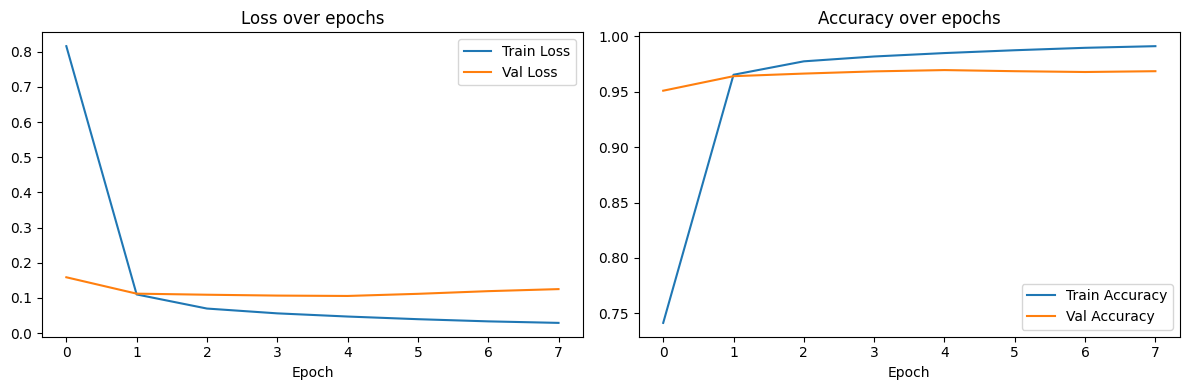

In [16]:
es_callback = keras.callbacks.EarlyStopping(monitor= "val_loss",
                                            patience= 3,
                                            restore_best_weights=True)

checkpoint_callback = keras.callbacks.ModelCheckpoint(filepath='best_model.keras',
                                                      monitor='val_loss',
                                                      save_best_only=True,
                                                      save_weights_only=False)

history = model.fit(x_train, y_train,
                    validation_data=(x_valid, y_valid),
                    epochs=20,
                    batch_size=256,
                    callbacks= [es_callback, checkpoint_callback])

import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()

os.makedirs('images', exist_ok=True)
plt.savefig('images/training_history.png', dpi=150)

plt.show()


## Evaluate on the Test Set

Evaluate the trained model on the held-out test set to measure final loss and accuracy on data it has never seen during training or validation.

In [17]:
model.evaluate(x_test, y_test)

 22/226 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9686 - loss: 0.1177

2026-09-13 17:01:45.762192: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9682 - loss: 0.1093


[0.10933573544025421, 0.9681961536407471]

## Test on Custom Sentences: "book" (NOUN vs VERB)

Test the model on two sentences using the word "book" in different grammatical roles, to check whether it can correctly disambiguate the tag based on sentence context rather than the word alone.

In [18]:
# "book" - NOUN vs VERB
samples = ["I read a good book .",
           "Please book a table for two .",]

samples_tokenize = sentence_tokenizer(samples).numpy()
print("samples tokenize shape:", samples_tokenize.shape)

print("=" * 50)

tags_of_samples = model.predict(samples_tokenize)
tags_of_samples = np.argmax(tags_of_samples, axis=-1)
print("tag shape:", tags_of_samples.shape)

print("=" * 50)

result = []
for i, sample in enumerate(samples):
    n_word = len(sample.split())

    sample_word = [index_to_word[idx] for idx in samples_tokenize[i, :n_word]]
    sample_tag = [index_to_tag[idx] for idx in tags_of_samples[i, :n_word]]
    result.append(list((str(w), str(t)) for w, t in zip(sample_word, sample_tag)))

for r in result:
    print(r)
    

samples tokenize shape: (2, 60)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
tag shape: (2, 60)
[('I', 'PRON'), ('read', 'VERB'), ('a', 'DET'), ('good', 'ADJ'), ('book', 'NOUN'), ('.', '.')]
[('Please', 'VERB'), ('book', 'VERB'), ('a', 'DET'), ('table', 'NOUN'), ('for', 'ADP'), ('two', 'NUM'), ('.', '.')]
